In [1]:

%load_ext autoreload
%autoreload 2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import sys, os
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/lcne_transcriptomics/')
sys.path.insert(0, '/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/')      
from lcne_transcriptomics import utils, plotting
import scvi

In [2]:
import glob

In [3]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M'])
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

In [4]:
# where the original data is saved
homedir = '/allen/aind/scratch/shuonan.chen/pons_images/'
reg_file_path = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/'
slicename_all = [os.path.basename(f).split('.')[0].split('registered_')[1] for f in glob.glob(reg_file_path+'*')]
slicename_all.sort()
len(slicename_all)

24

# load the data from csv file

In [5]:

sys.path.append('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/func/')
from prepare_img_utils import *
# from utils import get_paths
# paths = get_paths()
# print(paths.keys())

df = pd.read_csv("/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/dbh_pos_cells_all_OLD.csv", sep='\t', dtype={0: str})
# this is the stringent criterions 


In [6]:
df.head()

,neuron_id,x_CCF,y_CCF,z_CCF,8030451A03Rik,9130024F11Rik,9630002D21Rik,Abca13,Abi3bp,Adam33,...,Blank-61,Blank-62,Blank-63,Blank-64,Blank-65,Blank-66,Blank-67,Blank-68,Blank-69,slicename
0,103685216640203968188516774531086347883,409.606844,236.687088,179.309040,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MouseC_C2
1,104587908325765086675948399347513609206,407.892948,204.334839,265.870224,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MouseC_C2
2,107556232960175669029944473037950900912,409.104832,227.210884,174.501084,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MouseC_C2
3,110143770882700220040132120043038831763,407.519014,197.276290,266.738031,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MouseC_C2
4,113385467015087615676147138608792183276,410.125922,246.485426,165.601449,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MouseC_C2


# run cluster?

In [7]:
import anndata as ad
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [8]:
adata_mer.shape

(5473, 315)

In [9]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [10]:
np.unique(np.array(section_identifier_highlevel))

array(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'], dtype='<U7')

In [11]:
adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [12]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)
keptcellID = totalexpression>0  # Boolean to indicaet if all three marker genes have to be expre
adata_mer = adata_mer[keptcellID]

In [13]:
adata_mer.shape

(5473, 315)

In [14]:
adata_mer

View of AnnData object with n_obs × n_vars = 5473 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'mouse_name', 'mouse_sex'
    obsm: 'spatial'

# run scvi for batchnormalizations

In [15]:
import time

In [16]:
time1= time.time()
scvi.settings.seed = 1

adata_mer = adata_mer.copy()
scvi.model.SCVI.setup_anndata(adata_mer, batch_key="slicename")

# default layer =1, n_emb=128 , n_latent = 10
model = scvi.model.SCVI(adata_mer, n_latent=10, gene_likelihood="nb") 
model.train()
print('total time:', np.around((time.time()-time1)/60), 'minutes')

[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_p

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


total time: 4.0 minutes


In [17]:
umap_random_state = 307

adata_mer.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=.5,  random_state=umap_random_state)


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)
/scratch/fast/2403795/ipykernel_3507497/1817527248.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=.5,  random_state=umap_random_state)


... storing 'mouse_name' as categorical
... storing 'mouse_sex' as categorical


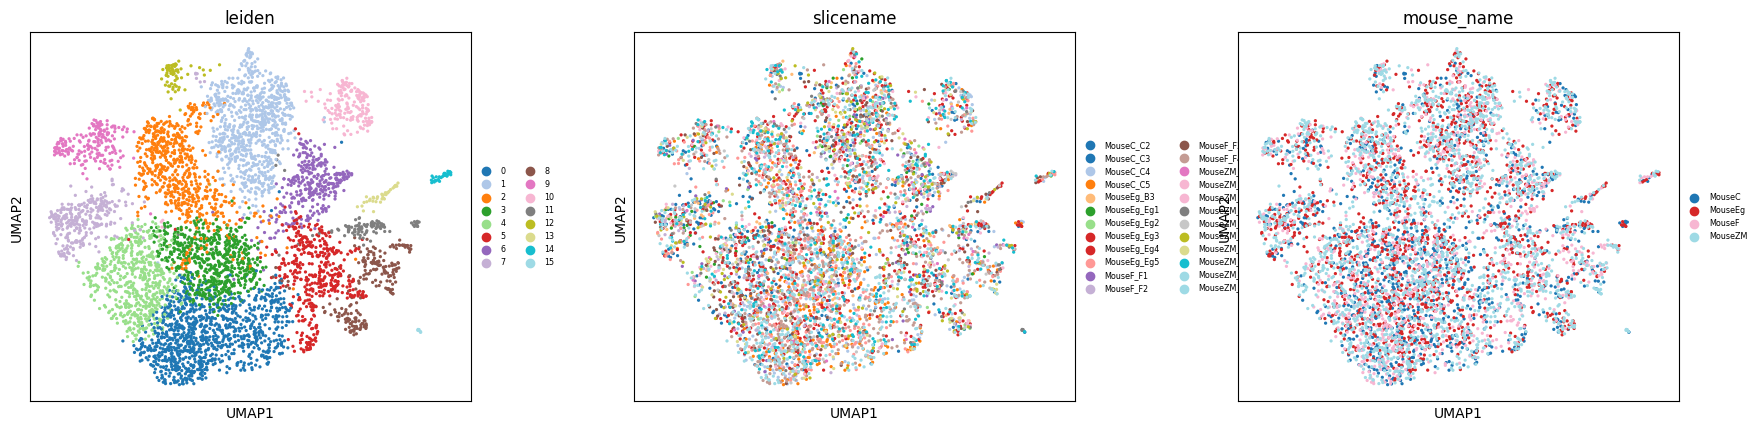

In [19]:
axes = sc.pl.umap(adata_mer, color=["leiden",'slicename','mouse_name'],
           legend_fontsize='xx-small',show = False,
           palette="tab20", cmap = 'Reds', ncols=4)
for a in axes:
    a.set_aspect('equal')
plt.show()    

# compute BN results

In [172]:
import anndata
adata_BN = model.get_normalized_expression(adata_mer, return_numpy=False, library_size = 10000)
adata_BN = anndata.AnnData(adata_BN)
adata_BN.obs = adata_mer.obs.copy()
adata_BN.obsm = adata_mer.obsm.copy()

# plot both BN and raw counts, try to identify the clusters

In [173]:
adata_mer.layers["log"] = np.log1p(adata_mer.X.copy())

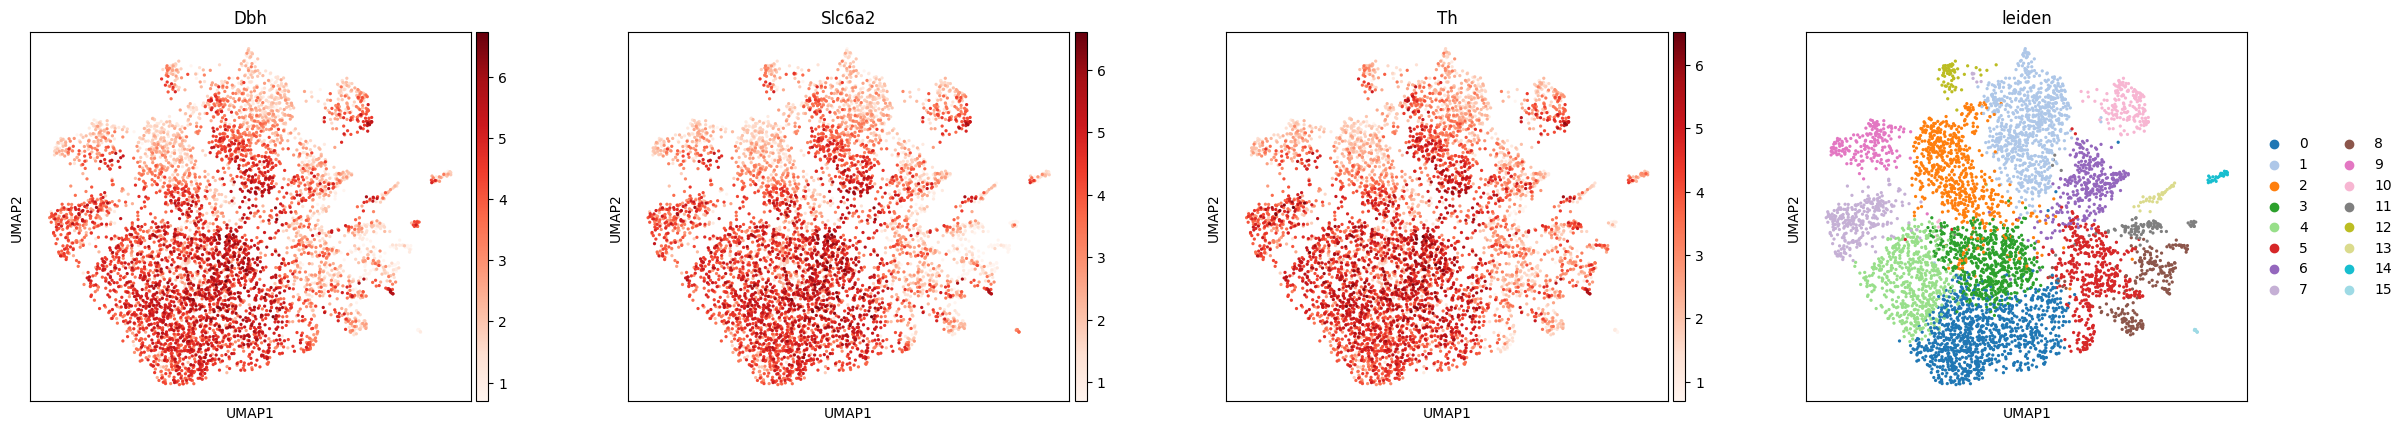

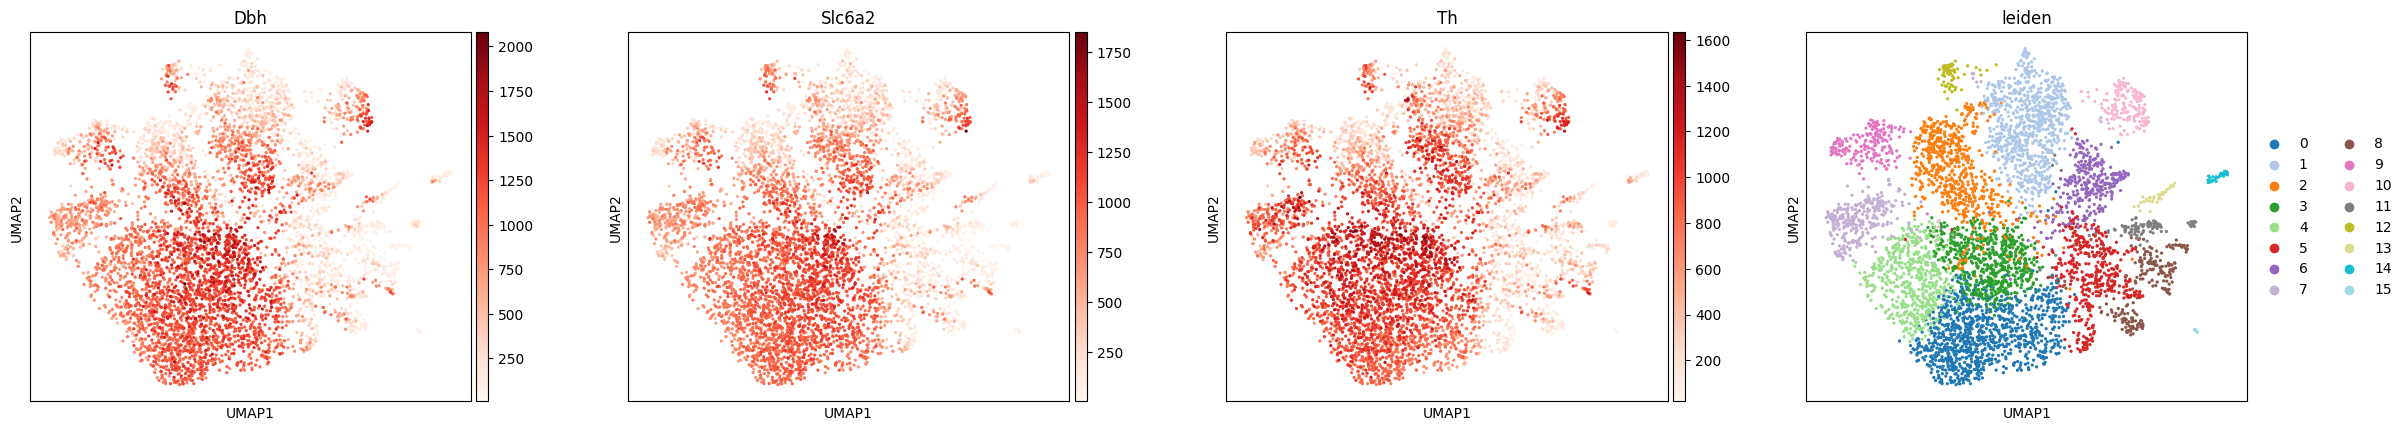

In [174]:
axes = sc.pl.umap(adata_mer, color=['Dbh','Slc6a2','Th','leiden'],layer="log",
           cmap ='Reds',ncols=4,palette="tab20",show = False) 
for a in axes:a.set_aspect('equal')

    
axes = sc.pl.umap(adata_BN, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=4,palette="tab20",show = False) 
for a in axes:a.set_aspect('equal')    

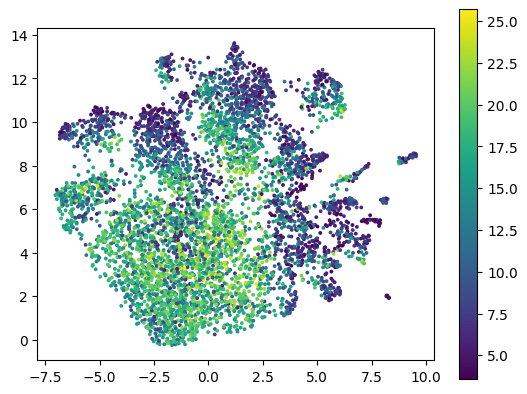

In [175]:
plt.scatter(adata_mer.obsm['X_umap'][:,0],adata_mer.obsm['X_umap'][:,1],
           c =np.sum(np.log1p(adata_mer[:,['Dbh','Th','Slc6a2','Slc18a2']].X),1),
           s=3)#,cmap ='bwr')
plt.colorbar()
plt.gca().set_aspect('equal')


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

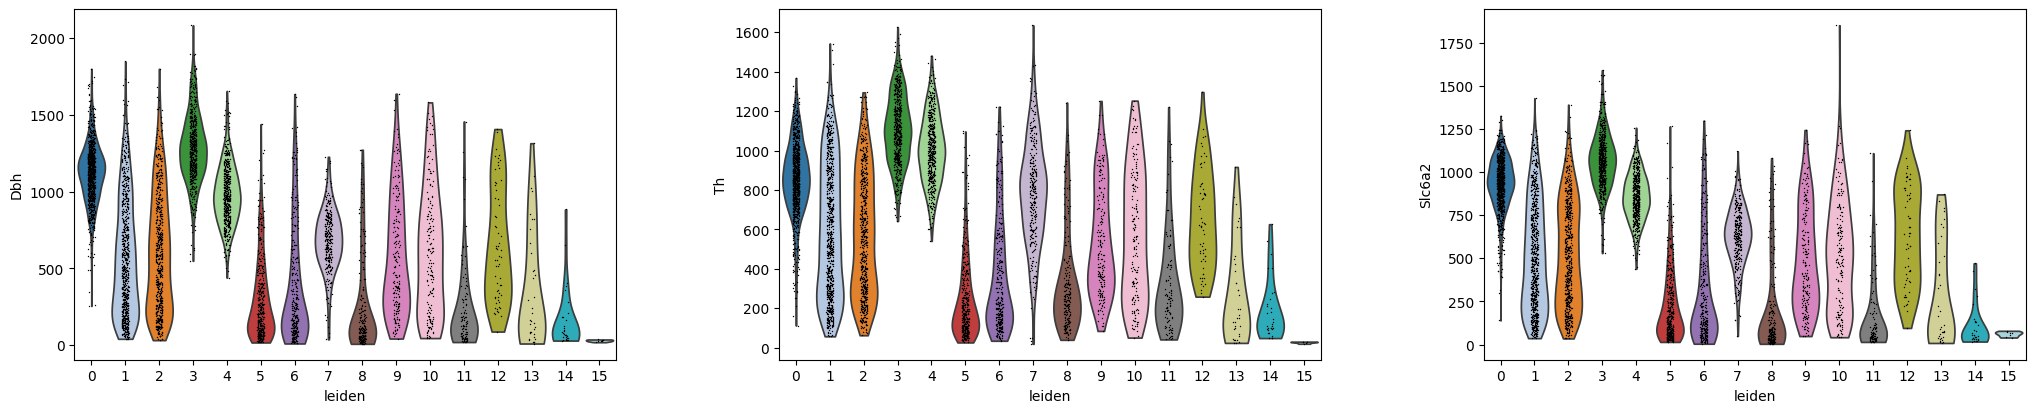

In [176]:
sc.pl.violin(adata_BN, ['Dbh','Th','Slc6a2'], groupby='leiden')

# choose subset based on the cluster here!

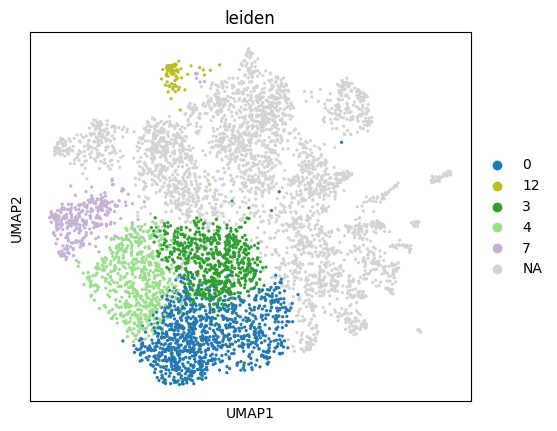

In [177]:
chosen_ks = [0,3,4,7,12]
axes = sc.pl.umap(adata_BN, color=['leiden'],groups = [str(k) for k in chosen_ks],cmap ='Reds',palette="tab20",show = False) 
axes.set_aspect('equal')

In [178]:
mask = adata_mer.obs['leiden'].isin([str(k) for k in chosen_ks]) 
adata_subset = adata_BN[mask].copy() 
print(f"Original size: {adata_mer.n_obs} cells")
print(f"Subset size: {adata_subset.n_obs} cells")
leidenmaskthingy = np.array(adata_subset.obs['leiden'].copy())

Original size: 5473 cells
Subset size: 2550 cells


In [179]:
allmeshes = utils.load_mesh()
mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
mesh.vertices /= 25 


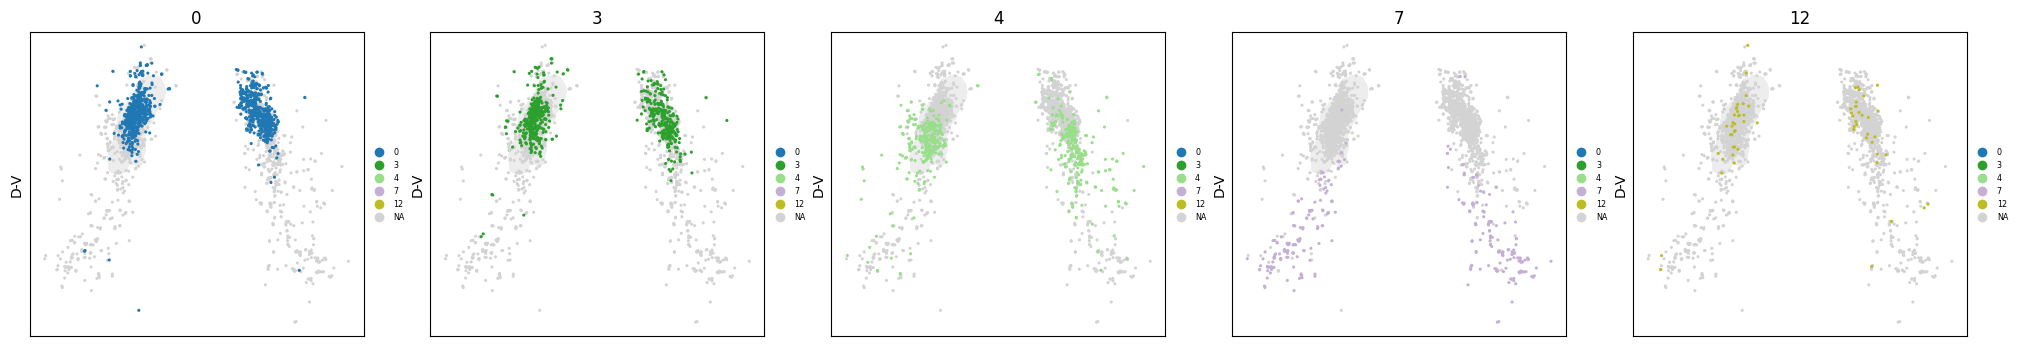

In [180]:

fig, axes = plt.subplots(1,len(chosen_ks),figsize=(25,4))
for i,k in enumerate(chosen_ks):    
    adata_subset = adata_BN[mask].copy() 
    plotting.plot_mesh(axes[i],mesh,direction = 'c')
    sc.pl.embedding(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',ax = axes[i],
                     dimensions = (2, 1),basis="spatial", size = 20,alpha = 1,
                     title=str(k), show=False, legend_fontsize='xx-small',)
    axes[i].set_aspect('equal')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')
    axes[i].set_xlabel('')

# pca 

In [181]:
np.sum(adata_subset.X,1)
adata_subset = adata_BN[mask].copy() 

In [182]:
adata_subset.X -= np.mean(adata_subset.X, 0)
std_gene = np.std(adata_subset.X, 0)
adata_subset.X /= std_gene
sc.tl.pca(adata_subset)

In [183]:
sc.pp.neighbors(adata_subset, use_rep="X_pca",  random_state=1)
sc.tl.umap(adata_subset, random_state=210,n_components=2)
# sc.tl.leiden(adata_subset, resolution=.5,  random_state=1)


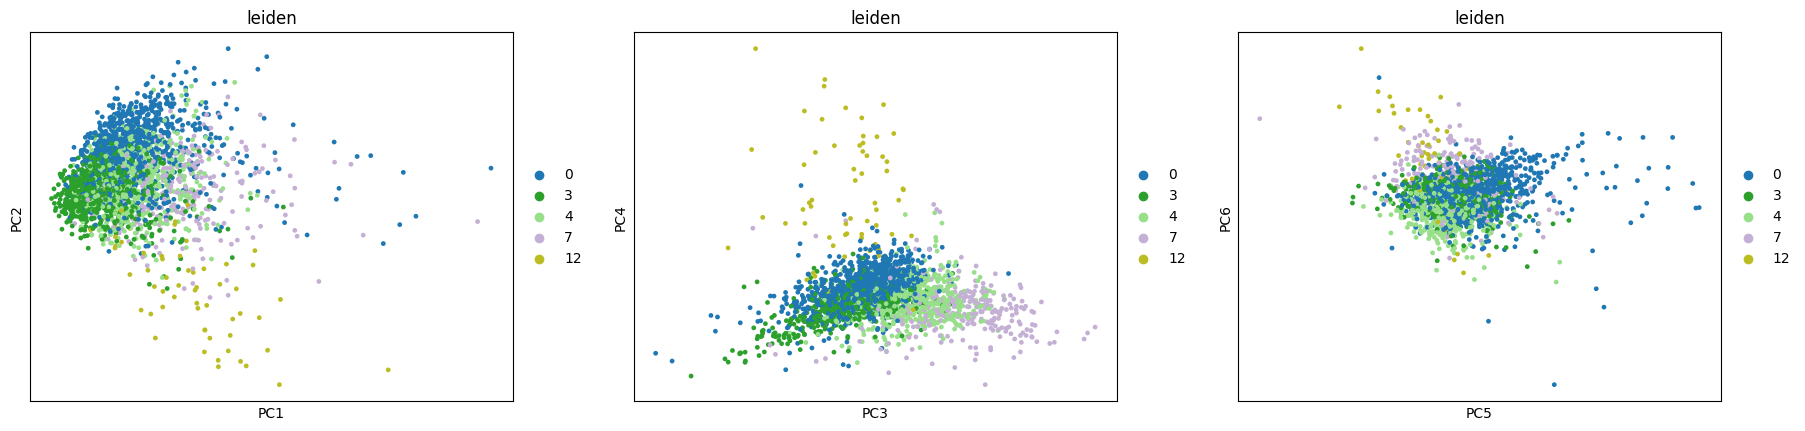

In [187]:
sc.pl.pca(adata_subset,dimensions = [(0,1),(2,3),(4,5)],color='leiden')

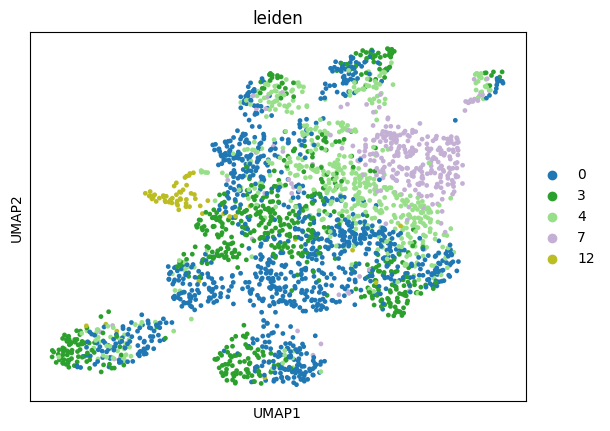

In [185]:
sc.pl.umap(adata_subset,color='leiden')

In [118]:
np.unique((adata_BN.obs['leiden'].values).astype(int)[mask])

array([ 0,  3,  4,  7, 12])

<Figure size 640x480 with 0 Axes>

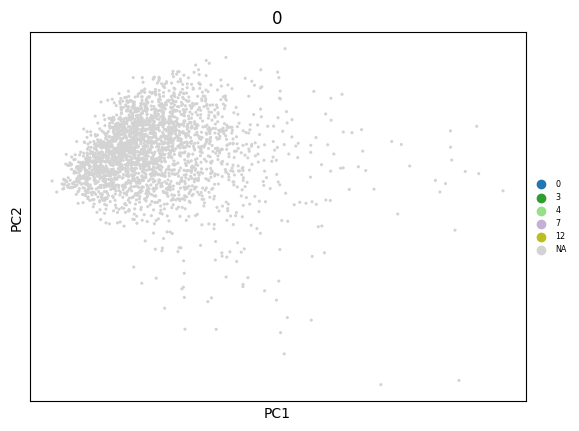

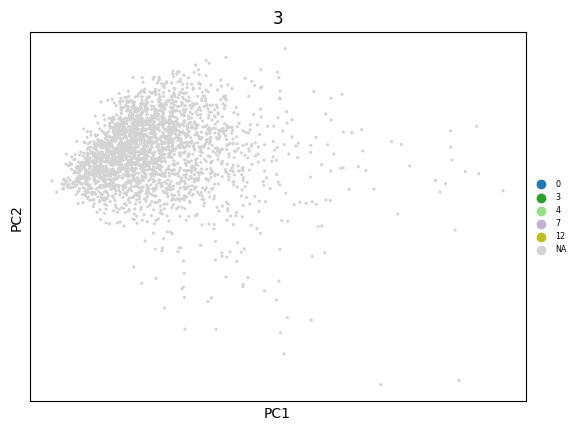

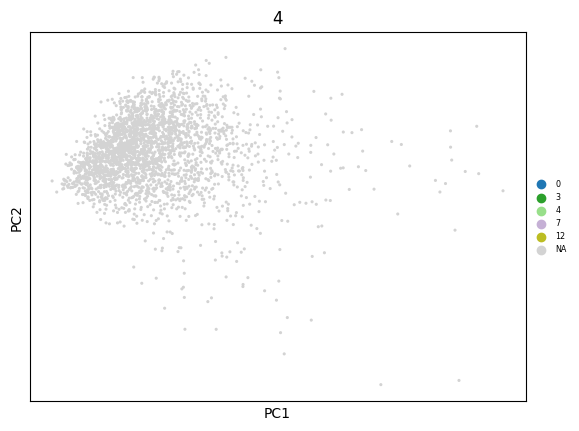

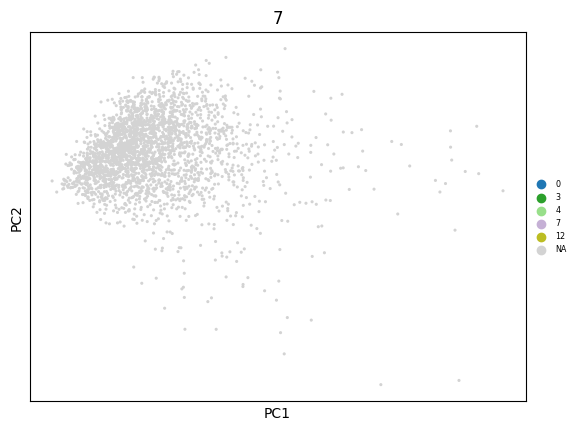

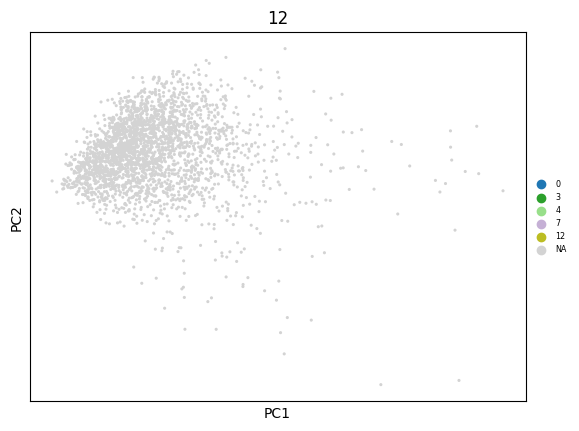

In [134]:
plt.figure()
for i,k in enumerate(chosen_ks):    
    sc.pl.pca(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',
              size = 20,alpha = 1,title=str(k), show=False, legend_fontsize='xx-small',)

In [132]:
plt.show()    

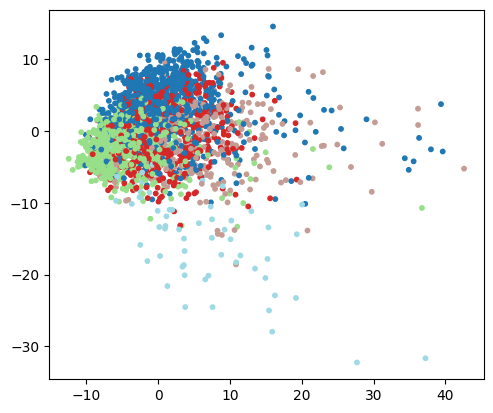

In [116]:

plt.scatter(adata_subset.obsm['X_pca'][:,0],adata_subset.obsm['X_pca'][:,1],
            s=10,c=(adata_BN.obs['leiden'].values).astype(int)[mask],cmap = 'tab20')
plt.gca().set_aspect('equal')

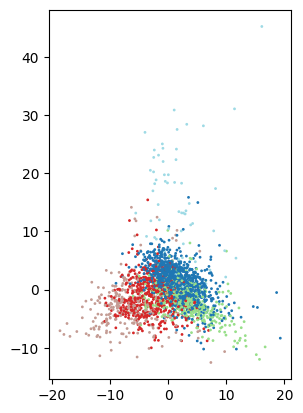

In [115]:

plt.scatter(adata_subset.obsm['X_pca'][:,2],adata_subset.obsm['X_pca'][:,3],
            s=1,c=(adata_BN.obs['leiden'].values).astype(int)[mask],cmap = 'tab20')
plt.gca().set_aspect('equal')

In [ ]:
# adata_BN.X -= np.mean(adata_BN.X, 0)
# std_gene = np.std(adata_BN.X, 0)
# adata_BN.X /= std_gene


sc.tl.pca(adata_BN)

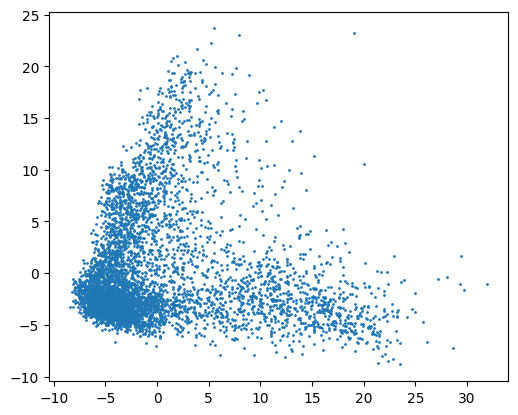

In [72]:
plt.scatter(adata_BN.obsm['X_pca'][:,0],adata_BN.obsm['X_pca'][:,1],s=1)
plt.gca().set_aspect('equal')

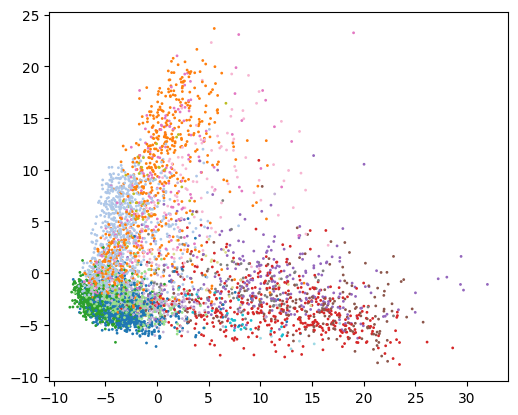

In [73]:
plt.scatter(adata_BN.obsm['X_pca'][:,0],adata_BN.obsm['X_pca'][:,1],s=1,
            c=(adata_BN.obs['leiden'].values).astype(int),cmap = 'tab20')
plt.gca().set_aspect('equal')